In [34]:
library(ape)
library(phangorn)
library(treeio)
library(ggtree)
library(ggplot2)
library(ape)
library(cowplot)
library(circlize)
library(ggtreeExtra)
library(ggnewscale)
library(tidyr)

metadata <- read.table('/syn1/liangzhen/jinhua_jilab_project/result/scRNA/cellranger/scRNA.metadata.csv',sep=',',header=T,row.names=1)
rownames(metadata) <- metadata$cellName

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“The column of x aesthetic only have one unique value with `geom = geom_tile`,
and the `width` of `geom_tile()` is not provided, the `pwidth` will be as
`width`.”


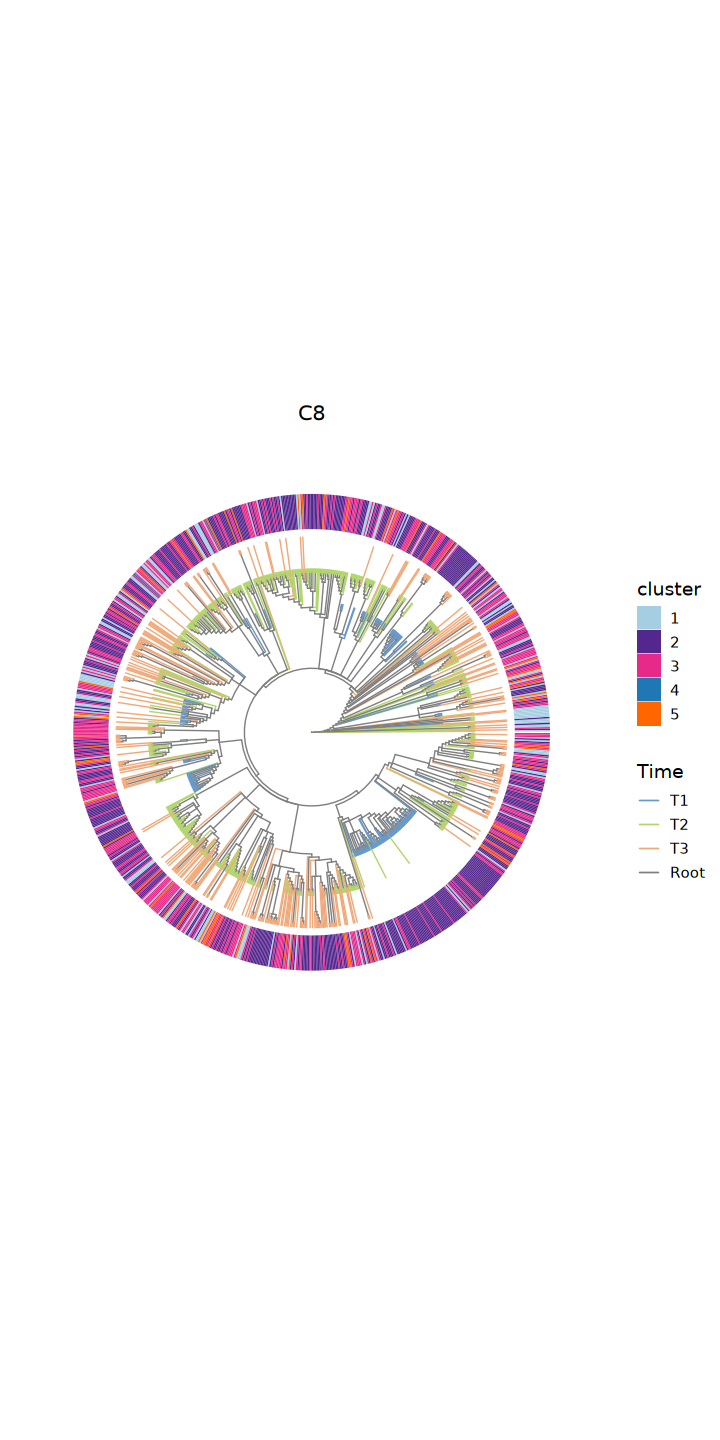

In [35]:
file <- 'C8-1012.phy.treefile'#'C100-103.phy.treefile'

tree <- read.tree(paste0('/syn1/liangzhen/jinhua_jilab_project/result/DNA_Amplicon/trees/merge_all_experiments/T1T2T3/final/',file))
tree <- root(tree, outgroup = "synthetic", resolve.root = TRUE)
tree <- drop.tip(tree,tree$tip.label[!(tree$tip.label %in% metadata$cellName)])

# 修改此处：添加 aes(color=Time) 映射
tree_plot <- ggtree(tree, layout = 'fan', open.angle = 0, branch.length='none', size=0.3, aes(color=Time))#layout = 'fan', open.angle = 0, 

# 为叶子节点赋值 Time
tree_plot$data$Time <- 'Root'
tree_plot$data[tree_plot$data$isTip==TRUE & tree_plot$data$label!='synthetic','Time'] <- metadata[tree_plot$data$label[tree_plot$data$isTip==TRUE & tree_plot$data$label!='synthetic'],'time']

# 为叶子节点赋值 cluster（用于热图）
tree_plot$data$cluster <- 'Root'
tree_plot$data[tree_plot$data$isTip==TRUE & tree_plot$data$label!='synthetic','cluster'] <- as.character(metadata[tree_plot$data$label[tree_plot$data$isTip==TRUE & tree_plot$data$label!='synthetic'],'tumor_state'])

# 找node下面大于两个相同叶子的节点
tree_plot$data$time <- tree_plot$data$Time 
tree_plot$data[tree_plot$data$Time=='T3','Time'] <- 'T2'

node_list <- c()
for (node in tree_plot$data$node[tree_plot$data$Time %in% c('T2')]){
    parent <- as.numeric(tree_plot$data[node,'parent'])
    subtree <- extract.clade(tree, parent)
    tip_names <- subtree$tip.label
    children <- as.data.frame(tree_plot$data[tree_plot$data$label %in% tip_names,'Time'])[,'Time']

    while (length(unique(children)) == 1){
        node_list <- c(node_list,parent)
        parent <- as.numeric(tree_plot$data[parent,'parent'])
        subtree <- extract.clade(tree, parent)
        tip_names <- subtree$tip.label
        children <- as.data.frame(tree_plot$data[tree_plot$data$label %in% tip_names,'Time'])[,'Time']
        
    }
    if(length(unique(children)) > 1){
        node_list <- c(node_list,node)
    }
}

# 找最接近祖先的node
node_list_filter <- unique(node_list)
for (node in unique(node_list)){
    if (node %in% tree_plot$data$parent){
        child_nodes <- as.data.frame(tree_plot$data[tree_plot$data$parent==node,'node'])[,'node'] 
        node_list_filter <- node_list_filter[! node_list_filter %in% child_nodes]
    }
    
}

for (node in node_list_filter){
    if(node %in% tree_plot$data$parent){   
        subtree <- extract.clade(tree, node)
        tip_names <- subtree$tip.label
        children <- as.data.frame(tree_plot$data[tree_plot$data$label %in% tip_names,'Time'])[,'Time']
        if (node==1455){
            next
        }
        #print(children )
        if (unique(children)=='T2'){
            #print(node)
            tree_plot$data[node,'x'] = tree_plot$data[node,'x'] + 10
            tree_plot$data[Descendants(tree, node, type = "all"),'x'] = tree_plot$data[Descendants(tree, node, type = "all"),'x'] + 10  
            
            
        }
    }
    
    if (as.data.frame(tree_plot$data[node,'Time'])[,'Time']=='T2'){
        
        tree_plot$data[node,'x'] = tree_plot$data[node,'x'] + 10
    }
}

tree_plot$data$Time <- tree_plot$data$time
node_list <- c()
for (node in tree_plot$data$node[tree_plot$data$Time %in% c('T3')]){
    parent <- as.numeric(tree_plot$data[node,'parent'])
    subtree <- extract.clade(tree, parent)
    tip_names <- subtree$tip.label
    children <- as.data.frame(tree_plot$data[tree_plot$data$label %in% tip_names,'Time'])[,'Time']

    while (length(unique(children)) == 1){
        node_list <- c(node_list,parent)
        parent <- as.numeric(tree_plot$data[parent,'parent'])
        subtree <- extract.clade(tree, parent)
        tip_names <- subtree$tip.label
        children <- as.data.frame(tree_plot$data[tree_plot$data$label %in% tip_names,'Time'])[,'Time']
        
    }
    if(length(unique(children)) > 1){
        node_list <- c(node_list,node)
    }
}

# 找最接近祖先的node
node_list_filter <- unique(node_list)
for (node in unique(node_list)){
    if (node %in% tree_plot$data$parent){
        child_nodes <- as.data.frame(tree_plot$data[tree_plot$data$parent==node,'node'])[,'node'] 
        node_list_filter <- node_list_filter[! node_list_filter %in% child_nodes]
    }
    
}

for (node in node_list_filter){
    if(node %in% tree_plot$data$parent){   
        subtree <- extract.clade(tree, node)
        tip_names <- subtree$tip.label
        children <- as.data.frame(tree_plot$data[tree_plot$data$label %in% tip_names,'Time'])[,'Time']
        if (node==1455){
            next
        }
        #print(children )
        if (unique(children)=='T3'){
            #print(node)
            tree_plot$data[node,'x'] = tree_plot$data[node,'x'] + 10
            tree_plot$data[Descendants(tree, node, type = "all"),'x'] = tree_plot$data[Descendants(tree, node, type = "all"),'x'] + 10  
            
            
        }
    }
    
    if (as.data.frame(tree_plot$data[node,'Time'])[,'Time']=='T3'){
        
        tree_plot$data[node,'x'] = tree_plot$data[node,'x'] + 10
    }
}
        
options(repr.plot.width=6, repr.plot.height=12)
plot <- tree_plot +
    # 为树图的边和节点添加颜色映射（Time）
    scale_color_manual(
        name = "Time",
        breaks = c('T1', 'T2', 'T3', 'Root'),
        values = c('#6699CC','#B1D66B','#F1A878','gray50'),
        guide = guide_legend(keywidth=1, keyheight=1, ncol=1)
    ) +
    new_scale_fill() +
    geom_fruit(
        geom=geom_tile,
        mapping=aes(fill=cluster),
        pwidth=max(tree_plot$data$x)*0.18,
        offset=0.13
    ) + 
    scale_fill_manual(
        name="cluster",
        breaks=c('1','2','3','4','5'),
        values=c('#a6cee3','#54278f','#e7298a','#1f77b4','#ff6600'),
        guide=guide_legend(keywidth=1, keyheight=1, ncol=1)
    ) + 
    ggtitle(unlist(strsplit(file,split = '-'))[1]) + 
    theme(
        legend.position="right",  # 改为显示图例
        plot.title = element_text(hjust = 0.5, size = 12, face = "bold")
    ) 

print(plot)

In [ ]:
file <- 'C8-1012.phy.treefile'#'C100-103.phy.treefile'

tree <- read.tree(paste0('/syn1/liangzhen/jinhua_jilab_project/result/DNA_Amplicon/trees/merge_all_experiments/T1T2T3/final/',file))
tree <- root(tree, outgroup = "synthetic", resolve.root = TRUE)
tree <- drop.tip(tree,tree$tip.label[!(tree$tip.label %in% metadata$cellName)])

# 修改此处：添加 aes(color=Time) 映射
tree_plot <- ggtree(tree, branch.length='none', size=0.3,color='#636363') + #layout = 'fan', open.angle = 0, 
                    geom_tippoint(aes(color=Time), size=1) 

# 为叶子节点赋值 Time
tree_plot$data$Time <- 'Root'
tree_plot$data[tree_plot$data$isTip==TRUE & tree_plot$data$label!='synthetic','Time'] <- metadata[tree_plot$data$label[tree_plot$data$isTip==TRUE & tree_plot$data$label!='synthetic'],'time']

# 为叶子节点赋值 cluster（用于热图）
tree_plot$data$cluster <- 'Root'
tree_plot$data[tree_plot$data$isTip==TRUE & tree_plot$data$label!='synthetic','cluster'] <- as.character(metadata[tree_plot$data$label[tree_plot$data$isTip==TRUE & tree_plot$data$label!='synthetic'],'tumor_state'])

# 找node下面大于两个相同叶子的节点
tree_plot$data$time <- tree_plot$data$Time 
tree_plot$data[tree_plot$data$Time=='T3','Time'] <- 'T2'

node_list <- c()
for (node in tree_plot$data$node[tree_plot$data$Time %in% c('T2')]){
    parent <- as.numeric(tree_plot$data[node,'parent'])
    subtree <- extract.clade(tree, parent)
    tip_names <- subtree$tip.label
    children <- as.data.frame(tree_plot$data[tree_plot$data$label %in% tip_names,'Time'])[,'Time']

    while (length(unique(children)) == 1){
        node_list <- c(node_list,parent)
        parent <- as.numeric(tree_plot$data[parent,'parent'])
        subtree <- extract.clade(tree, parent)
        tip_names <- subtree$tip.label
        children <- as.data.frame(tree_plot$data[tree_plot$data$label %in% tip_names,'Time'])[,'Time']
        
    }
    if(length(unique(children)) > 1){
        node_list <- c(node_list,node)
    }
}

# 找最接近祖先的node
node_list_filter <- unique(node_list)
for (node in unique(node_list)){
    if (node %in% tree_plot$data$parent){
        child_nodes <- as.data.frame(tree_plot$data[tree_plot$data$parent==node,'node'])[,'node'] 
        node_list_filter <- node_list_filter[! node_list_filter %in% child_nodes]
    }
    
}

for (node in node_list_filter){
    if(node %in% tree_plot$data$parent){   
        subtree <- extract.clade(tree, node)
        tip_names <- subtree$tip.label
        children <- as.data.frame(tree_plot$data[tree_plot$data$label %in% tip_names,'Time'])[,'Time']
        if (node==1455){
            next
        }
        #print(children )
        if (unique(children)=='T2'){
            #print(node)
            tree_plot$data[node,'x'] = tree_plot$data[node,'x'] + 10
            tree_plot$data[Descendants(tree, node, type = "all"),'x'] = tree_plot$data[Descendants(tree, node, type = "all"),'x'] + 10  
            
            
        }
    }
    
    if (as.data.frame(tree_plot$data[node,'Time'])[,'Time']=='T2'){
        
        tree_plot$data[node,'x'] = tree_plot$data[node,'x'] + 10
    }
}

tree_plot$data$Time <- tree_plot$data$time
node_list <- c()
for (node in tree_plot$data$node[tree_plot$data$Time %in% c('T3')]){
    parent <- as.numeric(tree_plot$data[node,'parent'])
    subtree <- extract.clade(tree, parent)
    tip_names <- subtree$tip.label
    children <- as.data.frame(tree_plot$data[tree_plot$data$label %in% tip_names,'Time'])[,'Time']

    while (length(unique(children)) == 1){
        node_list <- c(node_list,parent)
        parent <- as.numeric(tree_plot$data[parent,'parent'])
        subtree <- extract.clade(tree, parent)
        tip_names <- subtree$tip.label
        children <- as.data.frame(tree_plot$data[tree_plot$data$label %in% tip_names,'Time'])[,'Time']
        
    }
    if(length(unique(children)) > 1){
        node_list <- c(node_list,node)
    }
}

# 找最接近祖先的node
node_list_filter <- unique(node_list)
for (node in unique(node_list)){
    if (node %in% tree_plot$data$parent){
        child_nodes <- as.data.frame(tree_plot$data[tree_plot$data$parent==node,'node'])[,'node'] 
        node_list_filter <- node_list_filter[! node_list_filter %in% child_nodes]
    }
    
}

for (node in node_list_filter){
    if(node %in% tree_plot$data$parent){   
        subtree <- extract.clade(tree, node)
        tip_names <- subtree$tip.label
        children <- as.data.frame(tree_plot$data[tree_plot$data$label %in% tip_names,'Time'])[,'Time']
        if (node==1455){
            next
        }
        #print(children )
        if (unique(children)=='T3'){
            #print(node)
            tree_plot$data[node,'x'] = tree_plot$data[node,'x'] + 10
            tree_plot$data[Descendants(tree, node, type = "all"),'x'] = tree_plot$data[Descendants(tree, node, type = "all"),'x'] + 10  
            
            
        }
    }
    
    if (as.data.frame(tree_plot$data[node,'Time'])[,'Time']=='T3'){
        
        tree_plot$data[node,'x'] = tree_plot$data[node,'x'] + 10
    }
}
        
options(repr.plot.width=6, repr.plot.height=12)
plot <- tree_plot +
    # 为树图的边和节点添加颜色映射（Time）
    scale_color_manual(
        name = "Time",
        breaks = c('T1', 'T2', 'T3', 'Root'),
        values = c('#6699CC','#B1D66B','#F1A878','gray50'),
        guide = guide_legend(keywidth=1, keyheight=1, ncol=1)
    )+ 
    ggtitle(unlist(strsplit(file,split = '-'))[1]) + 
    theme(
        legend.position="right",  # 改为显示图例
        plot.title = element_text(hjust = 0.5, size = 12, face = "bold")
    ) 


tree_data <- tree_plot$data[tree_plot$data$isTip==TRUE,]
tree_data <- tree_data[order(tree_data$y,decreasing = T),] 
df_alleles <- read.table('/syn1/liangzhen/jinhua_jilab_project/result/DNA_Amplicon/trees/merge_all_experiments/T1T2T3/final/C8-1012.csv',header = T,sep=',',row.names=1,check.names = F)
df_alleles_test <- as.data.frame(apply(df_alleles, 2, as.character))
rownames(df_alleles_test) <- rownames(df_alleles)
df_alleles_test <- df_alleles_test[tree_data$label,]
colnames(df_alleles_test) <- seq(1:ncol(df_alleles_test))
df_alleles_test$index <- rownames(df_alleles_test)

df_alleles_test <- as.data.frame(pivot_longer(df_alleles_test,names_to = 'location',values_to = 'mutation',cols = -index))
df_alleles_test <- df_alleles_test[df_alleles_test$mutation != 0,]
df_alleles_test$location <- as.numeric(df_alleles_test$location)
snp_data <- df_alleles_test
snp_data

plot2 <- plot + geom_facet(
  panel = "Mutation",
  data = snp_data, 
  geom = geom_point,
  mapping = aes(x = location),  # 不使用 color = mutation 避免色彩混乱
  shape = '.',
  color = '#de2d26'               # 明确设定颜色
)+theme(
    panel.background = element_rect(fill = "#fcfbfd", color = NA),
    #plot.background = element_rect(fill = "#f0f0f0", color = NA),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.title = element_blank(),        # 去掉坐标轴标题
    axis.text = element_blank(),         # 去掉坐标轴刻度文本
    axis.ticks = element_blank(),        # 去掉坐标轴刻度线
    axis.line = element_blank()          # 去掉坐标轴线条
  )
print(plot2)

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


png 
  2

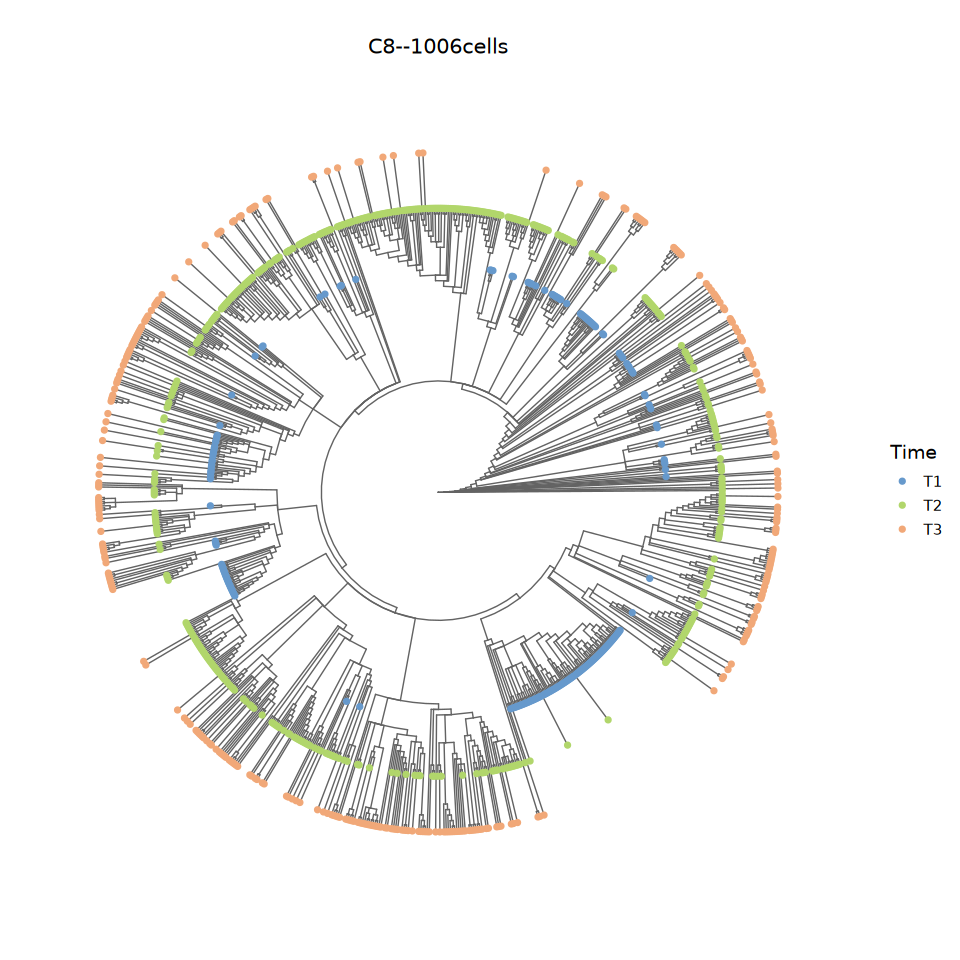

In [37]:
file <- 'C8-1012.phy.treefile'#'C100-103.phy.treefile'

tree <- read.tree(paste0('/syn1/liangzhen/jinhua_jilab_project/result/DNA_Amplicon/trees/merge_all_experiments/T1T2T3/final/',file))
tree <- root(tree, outgroup = "synthetic", resolve.root = TRUE)
tree <- drop.tip(tree,tree$tip.label[!(tree$tip.label %in% metadata$cellName)])

# 修改此处：添加 aes(color=Time) 映射
tree_plot <- ggtree(tree, layout = 'fan', open.angle = 0, branch.length='none', size=0.3,color='#636363') + #
                    geom_tippoint(aes(color=Time), size=1) 

# 为叶子节点赋值 Time
tree_plot$data$Time <- 'Root'
tree_plot$data[tree_plot$data$isTip==TRUE & tree_plot$data$label!='synthetic','Time'] <- metadata[tree_plot$data$label[tree_plot$data$isTip==TRUE & tree_plot$data$label!='synthetic'],'time']

# 为叶子节点赋值 cluster（用于热图）
tree_plot$data$cluster <- 'Root'
tree_plot$data[tree_plot$data$isTip==TRUE & tree_plot$data$label!='synthetic','cluster'] <- as.character(metadata[tree_plot$data$label[tree_plot$data$isTip==TRUE & tree_plot$data$label!='synthetic'],'tumor_state'])

# 找node下面大于两个相同叶子的节点
tree_plot$data$time <- tree_plot$data$Time 
tree_plot$data[tree_plot$data$Time=='T3','Time'] <- 'T2'

node_list <- c()
for (node in tree_plot$data$node[tree_plot$data$Time %in% c('T2')]){
    parent <- as.numeric(tree_plot$data[node,'parent'])
    subtree <- extract.clade(tree, parent)
    tip_names <- subtree$tip.label
    children <- as.data.frame(tree_plot$data[tree_plot$data$label %in% tip_names,'Time'])[,'Time']

    while (length(unique(children)) == 1){
        node_list <- c(node_list,parent)
        parent <- as.numeric(tree_plot$data[parent,'parent'])
        subtree <- extract.clade(tree, parent)
        tip_names <- subtree$tip.label
        children <- as.data.frame(tree_plot$data[tree_plot$data$label %in% tip_names,'Time'])[,'Time']
        
    }
    if(length(unique(children)) > 1){
        node_list <- c(node_list,node)
    }
}

# 找最接近祖先的node
node_list_filter <- unique(node_list)
for (node in unique(node_list)){
    if (node %in% tree_plot$data$parent){
        child_nodes <- as.data.frame(tree_plot$data[tree_plot$data$parent==node,'node'])[,'node'] 
        node_list_filter <- node_list_filter[! node_list_filter %in% child_nodes]
    }
    
}

for (node in node_list_filter){
    if(node %in% tree_plot$data$parent){   
        subtree <- extract.clade(tree, node)
        tip_names <- subtree$tip.label
        children <- as.data.frame(tree_plot$data[tree_plot$data$label %in% tip_names,'Time'])[,'Time']
        if (node==1455){
            next
        }
        #print(children )
        if (unique(children)=='T2'){
            #print(node)
            tree_plot$data[node,'x'] = tree_plot$data[node,'x'] + 10
            tree_plot$data[Descendants(tree, node, type = "all"),'x'] = tree_plot$data[Descendants(tree, node, type = "all"),'x'] + 10  
            
            
        }
    }
    
    if (as.data.frame(tree_plot$data[node,'Time'])[,'Time']=='T2'){
        
        tree_plot$data[node,'x'] = tree_plot$data[node,'x'] + 10
    }
}

tree_plot$data$Time <- tree_plot$data$time
node_list <- c()
for (node in tree_plot$data$node[tree_plot$data$Time %in% c('T3')]){
    parent <- as.numeric(tree_plot$data[node,'parent'])
    subtree <- extract.clade(tree, parent)
    tip_names <- subtree$tip.label
    children <- as.data.frame(tree_plot$data[tree_plot$data$label %in% tip_names,'Time'])[,'Time']

    while (length(unique(children)) == 1){
        node_list <- c(node_list,parent)
        parent <- as.numeric(tree_plot$data[parent,'parent'])
        subtree <- extract.clade(tree, parent)
        tip_names <- subtree$tip.label
        children <- as.data.frame(tree_plot$data[tree_plot$data$label %in% tip_names,'Time'])[,'Time']
        
    }
    if(length(unique(children)) > 1){
        node_list <- c(node_list,node)
    }
}

# 找最接近祖先的node
node_list_filter <- unique(node_list)
for (node in unique(node_list)){
    if (node %in% tree_plot$data$parent){
        child_nodes <- as.data.frame(tree_plot$data[tree_plot$data$parent==node,'node'])[,'node'] 
        node_list_filter <- node_list_filter[! node_list_filter %in% child_nodes]
    }
    
}

for (node in node_list_filter){
    if(node %in% tree_plot$data$parent){   
        subtree <- extract.clade(tree, node)
        tip_names <- subtree$tip.label
        children <- as.data.frame(tree_plot$data[tree_plot$data$label %in% tip_names,'Time'])[,'Time']
        if (node==1455){
            next
        }
        #print(children )
        if (unique(children)=='T3'){
            #print(node)
            tree_plot$data[node,'x'] = tree_plot$data[node,'x'] + 10
            tree_plot$data[Descendants(tree, node, type = "all"),'x'] = tree_plot$data[Descendants(tree, node, type = "all"),'x'] + 10  
            
            
        }
    }
    
    if (as.data.frame(tree_plot$data[node,'Time'])[,'Time']=='T3'){
        
        tree_plot$data[node,'x'] = tree_plot$data[node,'x'] + 10
    }
}

options(repr.plot.width=8, repr.plot.height=8)
pdf('/syn1/liangzhen/jinhua_jilab_project/result/Figures/Figure1/Clone8_time_series_tree.pdf',height=8,width=8)     
plot <- tree_plot +
    scale_color_manual(
        name = "Time",
        breaks = c('T1', 'T2', 'T3', 'Root'),
        values = c('#6699CC','#B1D66B','#F1A878','gray50'),
        guide = guide_legend(keywidth=1, keyheight=1, ncol=1)
    )+ 
    ggtitle(paste0(unlist(strsplit(file,split = '-'))[1],'--',length(tree$tip.label),'cells')) + 
    theme(
        legend.position="right",  # 改为显示图例
        plot.title = element_text(hjust = 0.5, size = 12, face = "bold")
    ) 
print(plot)
dev.off()
print(plot)